In [ ]:
import networkx as nx
import numpy as np
#import community.community_louvain
import community as community_louvain
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
def draw_graph(graph, title="", mylabels={}):
    pos = nx.spring_layout(graph, k=0.3, iterations=50, seed=2)
    plt.figure(1,figsize=(25,45))
    nx.draw(graph,
        pos = pos,
        node_color='pink',
        node_size=4000,
        #labels=mylabels,
        with_labels=True,
        font_size = 16,
        font_color='black')
    plt.title(label=title, fontsize=40, color="green")
    edge_labels = dict([((n1, n2), d['rel_type'])#
                    for n1, n2, d in graph.edges(data=True)])
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, label_pos=0.5, font_color='green', font_size=20, font_weight='bold')
    plt.show()

In [ ]:
def draw_community(graph, partitionGraph, title=""):
    plt.figure(1,figsize=(25,70))
    
    shapes = 'so^>v<dph.12348P*hH+xXD|,so^>v<dph.12348P*hH+xXD|,so^>v<dph.12348P*hH+xXD|'
    pos = nx.spring_layout(graph, k=0.3, iterations=50, seed=2) 
    cmap = cm.get_cmap('viridis', max(partitionGraph.values()) + 1)
    
    for node, clstr in partitionGraph.items():
        nx.draw_networkx_nodes(partitionGraph, pos, [node], node_size=2000, 
                               node_color=[cmap.colors[clstr]], 
                               node_shape=shapes[clstr])
    
    nx.draw_networkx_labels(graph,pos, font_size=12,font_family='sans-serif')
    
    nx.draw_networkx_edges(graph, pos, alpha=0.5)
    edge_labels = dict([((n1, n2), d['rel_type']) for n1, n2, d in graph.edges(data=True)])    
    nx.draw_networkx_edge_labels(partitionGraph, pos, edge_labels=edge_labels, label_pos=0.5, font_color='green', font_size=12, font_weight='normal')
    
    
    plt.title(label=title, fontsize=40, color="green")
    plt.show()

# 1. Athena

In [ ]:
H = nx.read_graphml('GL10appsDataGraphs/athena.gml')
G = nx.Graph(H) # create an undirected graph G from a directed graph H

G.number_of_edges() #184
G.number_of_nodes() #102

In [ ]:
draw_graph(G,"Graph without clusters",None)

### 1.1 Louvain Community (best partition)

In [ ]:
# compute the best partition
#community.best_partition(graph, partition=None, weight=’weight’, resolution=1.0, randomize= None, random_state=None)
partition = community_louvain.best_partition(G)
#print(partition)
#print("max partition values", max(partition.values()))
#print("total", len(partition.values()))
#print(partition.keys())

In [ ]:
draw_community(G,partition,"Athena Communities")

#### 1.1.1 Write best-partition to excel

In [ ]:
partition_df = pd.DataFrame([partition])
#print (partition_df)

In [ ]:
#import json
#with open('GL10appsDataGraphs/athena-community.csv', 'w') as convert_file:
 #       convert_file.write(json.dumps(partition))

In [ ]:
with pd.ExcelWriter('GL10appsDataGraphs/Louvain-community-all.xlsx') as writer:  
    partition_df.to_excel(writer, sheet_name='Athena')

 ### 1.2 Louvain Community Dendogram

In [ ]:
#community.generate_dendrogram(graph, part_init=None, weight=’weight’, resolution=1.0, randomize=None, random_state=None)
athenaDendo = community_louvain.generate_dendrogram(G)

In [ ]:
len(athenaDendo)

In [ ]:
#print the dendogram cluster wrt each level
for level in range(len(athenaDendo) - 1) :
    print("partition at level", level, "is", community_louvain.partition_at_level(athenaDendo, level), "\n")

 #### 1.2.1 Louvain community - get each level from dendogram

In [ ]:
#Level 0
athenaPart0 = community_louvain.partition_at_level(athenaDendo, 0)


In [ ]:
#Level 1
athenaPart1 = community_louvain.partition_at_level(athenaDendo, 1)


In [ ]:
#Level 2
athenaPart2 = community_louvain.partition_at_level(athenaDendo, 2)

#### 1.2.2 Louvain community - draw each level from dendogram

In [ ]:
#draw_graph(athenaPart0,"Athena Community Level 0",None)
draw_community(G,athenaPart0,"Athena Community Level 0")

In [ ]:
#draw_graph(athenaPart1,"Athena Community Level 1",None)
draw_community(G,athenaPart1,"Athena Community Level 1")

In [ ]:
#draw_graph(athenaPart2,"Athena Community Level 2",None)
draw_community(G,athenaPart2,"Athena Community Level 2")

#### 1.2.3 save louvain dendogram to excel wrt levels

In [ ]:
#convert the partition dictionary to the dataframe
athenaPart0_df = pd.DataFrame([athenaPart0])
athenaPart1_df = pd.DataFrame([athenaPart1])
athenaPart2_df = pd.DataFrame([athenaPart2])

#write to the excel each partition on each sheet
with pd.ExcelWriter('GL10appsDataGraphs/Louvain-AthenaCommunity.xlsx') as writer:  
    athenaPart0_df.to_excel(writer, sheet_name='AthenaL0')
    athenaPart1_df.to_excel(writer, sheet_name='AthenaL1')
    athenaPart2_df.to_excel(writer, sheet_name='AthenaL2')

# 2.  Educational-Management

In [ ]:
I = nx.read_graphml('GL10appsDataGraphs/educational-management.gml')
J = nx.Graph(I) # create an undirected graph G from a directed graph H

J.number_of_edges() #184
J.number_of_nodes() #102

In [ ]:
draw_graph(J,"Graph without clusters",None)

### 2.1 Louvain Community (best partition)

In [ ]:
# compute the best partition
#community.best_partition(J, partition=None, weight=’weight’, resolution=1.0, randomize= None, random_state=None)
EduMgmtPartition = community_louvain.best_partition(J)
#print(partition)
#print("max partition values", max(partition.values()))
#print("total", len(partition.values()))
#print(partition.keys())

In [ ]:
draw_community(J, EduMgmtPartition,"Educational-management Communities")

#### 2.1.1 Write best-partition to excel

In [ ]:
EduMgmt_df = pd.DataFrame([EduMgmtPartition])
#print (EduMgmt_df)
with pd.ExcelWriter('GL10appsDataGraphs/Louvain-community-all.xlsx') as writer:  
    EduMgmt_df.to_excel(writer, sheet_name='EduMgmt')

### 2.2 Louvain Community Dendogram

In [ ]:
#community.generate_dendrogram(J, part_init=None, weight=’weight’, resolution=1.0, randomize=None, random_state=None)
EduMgmtDendo = community_louvain.generate_dendrogram(J)

In [ ]:
len(EduMgmtDendo)

In [ ]:
#print the dendogram cluster wrt each level
for level in range(len(EduMgmtDendo)) :
    print("partition at level", level, "is", community_louvain.partition_at_level(EduMgmtDendo, level), "\n")

#### 2.2.1 Louvain community - get each level from dendogram

In [ ]:
#Level 0
EduMgmtPart0 = community_louvain.partition_at_level(EduMgmtDendo, 0)

In [ ]:
#Level 1
EduMgmtPart1 = community_louvain.partition_at_level(EduMgmtDendo, 1)

In [ ]:
#Level 2
EduMgmtPart2 = community_louvain.partition_at_level(EduMgmtDendo, 2)

#### 2.2.2 Louvain community - draw each level from dendogram

In [ ]:
#draw_graph(EduMgmtPart0,"Education Management Community Level 0",None)
draw_community(J,EduMgmtPart0,"Education Management Community Level 0")

In [ ]:
#draw_graph(EduMgmtPart1,"Education Management Community Level 1",None)
draw_community(J,EduMgmtPart1,"Education Management Community Level 1")

In [ ]:
#draw_graph(EduMgmtPart2,"Education Management Community Level 2",None)
draw_community(J,EduMgmtPart2,"Education Management Community Level 2")

#### 2.2.3 save louvain dendogram to excel wrt levels

In [ ]:
#convert the partition dictionary to the dataframe
EduMgmtPart0_df = pd.DataFrame([EduMgmtPart0])
EduMgmtPart1_df = pd.DataFrame([EduMgmtPart1])
EduMgmtPart2_df = pd.DataFrame([EduMgmtPart2])

#write to the excel each partition on each sheet
with pd.ExcelWriter('GL10appsDataGraphs/Louvain-EduMgmtCommunity.xlsx') as writer:  
    EduMgmtPart0_df.to_excel(writer, sheet_name='EduMgmt0')
    EduMgmtPart1_df.to_excel(writer, sheet_name='EduMgmt1')
    EduMgmtPart2_df.to_excel(writer, sheet_name='EduMgmt2')

# 3.  Exam-System

In [ ]:
K = nx.read_graphml('GL10appsDataGraphs/exam-system.gml')
L = nx.Graph(K) # create an undirected graph G from a directed graph H

L.number_of_edges()
L.number_of_nodes()

draw_graph(L,"Graph without clusters",None)

### 3.1 Louvain Community (best partition)

In [ ]:
# compute the best partition
#community.best_partition(graph, partition=None, weight=’weight’, resolution=1.0, randomize= None, random_state=None)
ExamSysPartition = community_louvain.best_partition(L)
#print(partition)
#print("max partition values", max(partition.values()))
#print("total", len(partition.values()))
#print(partition.keys())

In [ ]:
draw_community(L,ExamSysPartition ,"Exam System Management Communities")

#### 3.1.1 Write best-partition to excel

In [ ]:
ExamSysMgmt_df = pd.DataFrame([ExamSysPartition])
with pd.ExcelWriter('GL10appsDataGraphs/Louvain-community-all.xlsx') as writer:  
    ExamSysMgmt_df.to_excel(writer, sheet_name='ExamSys')

 ### 3.2 Louvain Community Dendogram

In [ ]:
#community.generate_dendrogram(graph, part_init=None, weight=’weight’, resolution=1.0, randomize=None, random_state=None)
ExamSysDendo = community_louvain.generate_dendrogram(L)

In [ ]:
len(ExamSysDendo)

In [ ]:
#print the dendogram cluster wrt each level
for level in range(len(ExamSysDendo)) :
    print("partition at level", level, "is", community_louvain.partition_at_level(ExamSysDendo, level), "\n")

 #### 3.2.1 Louvain community - get each level from dendogram

In [ ]:
#Level 0
ExamSysPart0 = community_louvain.partition_at_level(ExamSysDendo, 0)

In [ ]:
#Level 1
ExamSysPart1 = community_louvain.partition_at_level(ExamSysDendo, 1)

#### 3.2.2 Louvain community - draw each level from dendogram

In [ ]:
#draw_graph(athenaPart0,"Athena Community Level 0",None)
draw_community(L,ExamSysPart0,"Exam System Community Level 0")

In [ ]:
#draw_graph(athenaPart0,"Athena Community Level 0",None)
draw_community(L,ExamSysPart1,"Exam System Community Level 1")

#### 3.2.3 save louvain dendogram to excel wrt levels

In [ ]:
#convert the partition dictionary to the dataframe
ExamSysPart0_df = pd.DataFrame([ExamSysPart0])
ExamSysPart1_df = pd.DataFrame([ExamSysPart1])

#write to the excel each partition on each sheet
with pd.ExcelWriter('GL10appsDataGraphs/Louvain-ExamSystemCommunity.xlsx') as writer:  
    ExamSysPart0_df.to_excel(writer, sheet_name='ExamSys0')
    ExamSysPart1_df.to_excel(writer, sheet_name='ExamSys1')

# 4.  Jpetstore

In [ ]:
H = nx.read_graphml('GL10appsDataGraphs/jpetstore.gml')
M = nx.Graph(H) # create an undirected graph G from a directed graph H
M.number_of_edges()
M.number_of_nodes()

draw_graph(M,"Graph without clusters",None)

### 4.1 Louvain Community (best partition)

In [ ]:
jpetStorePartition = community_louvain.best_partition(M)
draw_community(M,jpetStorePartition ,"JPetStore Communities")

#### 4.1.1 Write best-partition to excel

In [ ]:
jpetStorePartition_df = pd.DataFrame([jpetStorePartition])
with pd.ExcelWriter('GL10appsDataGraphs/JPetStore-community-all.xlsx') as writer:  
    jpetstorePartition_df.to_excel(writer, sheet_name='jpetstore')

### 4.2 Louvain Community Dendogram

In [ ]:
#community.generate_dendrogram(graph, part_init=None, weight=’weight’, resolution=1.0, randomize=None, random_state=None)
jpetstoreDendo = community_louvain.generate_dendrogram(M)

In [ ]:
len(jpetstoreDendo)

In [ ]:
#print the dendogram cluster wrt each level
for level in range(len(jpetstoreDendo)) :
    print("partition at level", level, "is", community_louvain.partition_at_level(jpetstoreDendo, level), "\n")

#### 4.2.1 Louvain community - get each level from dendogram

In [ ]:
#Level 0
jpetstorePart0 = community_louvain.partition_at_level(jpetstoreDendo, 0)

In [ ]:
#Level 1
jpetstorePart1 = community_louvain.partition_at_level(jpetstoreDendo, 1)

#### 4.2.2 Louvain community - draw each level from dendogram

In [ ]:
#draw_graph(athenaPart0,"jpetstore Community Level 0",None)
draw_community(M,jpetstorePart0,"jpetstore Community Level 0")

In [ ]:
#draw_graph(athenaPart1,"jpetstore Community Level 1",None)
draw_community(M,jpetstorePart1,"jpetstore Community Level 1")

#### 4.2.3 save louvain dendogram to excel wrt levels

In [ ]:
#convert the partition dictionary to the dataframe
jpetstorePart0_df = pd.DataFrame([jpetstorePart0])
jpetstorePart1_df = pd.DataFrame([jpetstorePart1])

#write to the excel each partition on each sheet
with pd.ExcelWriter('GL10appsDataGraphs/Louvain-jpetstoreCommunity.xlsx') as writer:  
    jpetstorePart0_df.to_excel(writer, sheet_name='jpetstore0')
    jpetstorePart1_df.to_excel(writer, sheet_name='jpetstore1')

# 5.  Metel-SOS

In [ ]:
H = nx.read_graphml('GL10appsDataGraphs/metel-sos.gml')
N = nx.Graph(H) # create an undirected graph G from a directed graph H

N.number_of_edges()
N.number_of_nodes()

draw_graph(N,"Graph without clusters",None)

### 5.1 Louvain Community (best partition)

In [ ]:
metelSOSPartition = community_louvain.best_partition(N)
draw_community(N,metelSOSPartition ,"metel-SOS Communities")

#### 5.1.1 Write best-partition to excel

In [ ]:
metelSOS_df = pd.DataFrame([metelSOSPartition])
with pd.ExcelWriter('GL10appsDataGraphs/Louvain-community-all.xlsx') as writer:  
    metelSOS_df.to_excel(writer, sheet_name='metelSOS')

 ### 5.2 Louvain Community Dendogram

In [ ]:
#community.generate_dendrogram(graph, part_init=None, weight=’weight’, resolution=1.0, randomize=None, random_state=None)
metelSOSDendo = community_louvain.generate_dendrogram(N)

In [ ]:
len(metelSOSDendo)

In [ ]:
#print the dendogram cluster wrt each level
for level in range(len(metelSOSDendo)) :
    print("partition at level", level, "is", community_louvain.partition_at_level(metelSOSDendo, level), "\n")

 #### 5.2.1 Louvain community - get each level from dendogram

In [ ]:
#Level 0
metelSOSPart0 = community_louvain.partition_at_level(metelSOSDendo, 0)

In [ ]:
#Level 1
metelSOSPart1 = community_louvain.partition_at_level(metelSOSDendo, 1)

In [ ]:
#Level 2
metelSOSPart2 = community_louvain.partition_at_level(metelSOSDendo, 2)

#### 5.2.2 Louvain community - draw each level from dendogram

In [ ]:
#draw_graph(metelSOSPart0,"metelSOS Community Level 0",None)
draw_community(N,metelSOSPart0,"metelSOS Community Level 0")

In [ ]:
#draw_graph(metelSOSPart1,"metelSOS Community Level 1",None)
draw_community(N,metelSOSPart1,"metelSOS Community Level 1")

In [ ]:
#draw_graph(metelSOSPart1,"metelSOS Community Level 1",None)
draw_community(N,metelSOSPart2,"metelSOS Community Level 2")

#### 5.2.3 save louvain dendogram to excel wrt levels

In [ ]:
#convert the partition dictionary to the dataframe
metelSOSPart0_df = pd.DataFrame([metelSOSPart0])
metelSOSPart1_df = pd.DataFrame([metelSOSPart1])
metelSOSPart2_df = pd.DataFrame([metelSOSPart2])

#write to the excel each partition on each sheet
with pd.ExcelWriter('GL10appsDataGraphs/Louvain-metelSOSCommunity.xlsx') as writer:  
    metelSOSPart0_df.to_excel(writer, sheet_name='metelSOS0')
    metelSOSPart1_df.to_excel(writer, sheet_name='metelSOS1')
    metelSOSPart2_df.to_excel(writer, sheet_name='metelSOS2')

# 6.  Monolith-to-Microservices

In [ ]:
G = nx.read_graphml('GL10appsDataGraphs/monolith-to-microservices.gml')
O = nx.Graph(G) # create an undirected graph G from a directed graph H

O.number_of_edges()
O.number_of_nodes()

draw_graph(O,"Graph without clusters",None)

### 6.1 Louvain Community (best partition)

In [ ]:
monolith2microservicesPartition = community_louvain.best_partition(O)
draw_community(O,monolith2microservicesPartition ,"monolith to microservices Communities")

#### 6.1.1 Write best-partition to excel

In [ ]:
monolith2microservices_df = pd.DataFrame([monolith2microservicesPartition])
with pd.ExcelWriter('GL10appsDataGraphs/Louvain-community-all.xlsx') as writer:  
    monolith2microservices_df.to_excel(writer, sheet_name='monolith2microservices')

### 6.2 Louvain Community Dendogram

In [ ]:
#community.generate_dendrogram(graph, part_init=None, weight=’weight’, resolution=1.0, randomize=None, random_state=None)
monolithic2MicroDendo = community_louvain.generate_dendrogram(O)

In [ ]:
len(monolithic2MicroDendo)

In [ ]:
#print the dendogram cluster wrt each level
for level in range(len(monolithic2MicroDendo)) :
    print("partition at level", level, "is", community_louvain.partition_at_level(monolithic2MicroDendo, level), "\n")

#### 6.2.1 Louvain community - get each level from dendogram

In [ ]:
#Level 0
monolithic2MicroPart0 = community_louvain.partition_at_level(monolithic2MicroDendo, 0)


In [ ]:
#Level 1
monolithic2MicroPart1 = community_louvain.partition_at_level(monolithic2MicroDendo, 1)


In [ ]:
#draw_graph(monolithic2MicroPart1,"monolith2microservices Community Level 1",None)
draw_community(O, monolithic2MicroPart0,"monolith2microservices Community Level 0")

In [ ]:
#draw_graph(monolithic2MicroPart2,"monolith2microservices Community Level 1",None)
draw_community(O, monolithic2MicroPart1,"monolith2microservices Community Level 1")

#### 6.2.3 save louvain dendogram to excel wrt levels

In [ ]:
#convert the partition dictionary to the dataframe
monolithic2MicroPart0_df = pd.DataFrame([monolithic2MicroPart0])
monolithic2MicroPart1_df = pd.DataFrame([monolithic2MicroPart1])

#write to the excel each partition on each sheet
with pd.ExcelWriter('GL10appsDataGraphs/Louvain-monolith2microservicesCommunity.xlsx') as writer:  
    monolithic2MicroPart0_df.to_excel(writer, sheet_name='monolith2microservices0')
    monolithic2MicroPart1_df.to_excel(writer, sheet_name='monolith2microservices1')
    

# 7.  Nanfeng

In [ ]:
G = nx.read_graphml('GL10appsDataGraphs/nanfeng.gml')
P = nx.Graph(G) # create an undirected graph G from a directed graph H

P.number_of_edges()
P.number_of_nodes()

draw_graph(P,"Graph without clusters",None)

### 7.1 Louvain Community (best partition)

In [ ]:
nanfengPartition = community_louvain.best_partition(P)
draw_community(P,nanfengPartition ,"nanfeng Communities")

#### 7.1.1 Write best-partition to excel

In [ ]:
nanfeng_df = pd.DataFrame([nanfengPartition])
with pd.ExcelWriter('GL10appsDataGraphs/Louvain-community-all.xlsx') as writer:  
    nanfeng_df.to_excel(writer, sheet_name='nanfeng')

 ### 7.2 Louvain Community Dendogram

In [ ]:
#community.generate_dendrogram(graph, part_init=None, weight=’weight’, resolution=1.0, randomize=None, random_state=None)
nanfengDendo = community_louvain.generate_dendrogram(P)

In [ ]:
len(nanfengDendo)

In [ ]:
#print the dendogram cluster wrt each level
for level in range(len(nanfengDendo)) :
    print("partition at level", level, "is", community_louvain.partition_at_level(nanfengDendo, level), "\n")

 #### 7.2.1 Louvain community - get each level from dendogram

In [ ]:
#Level 0
nanfengPart0 = community_louvain.partition_at_level(nanfengDendo, 0)

In [ ]:
#Level 1
nanfengPart1 = community_louvain.partition_at_level(nanfengDendo, 1)

#### 7.2.2 Louvain community - draw each level from dendogram

In [ ]:
#draw_graph(athenaPart0,"nanfeng Community Level 0",None)
draw_community(P,nanfengPart0,"nanfeng Community Level 0")

In [ ]:
#draw_graph(athenaPart0,"nanfeng Community Level 0",None)
draw_community(P,nanfengPart1,"nanfeng Community Level 1")

#### 7.2.3 save louvain dendogram to excel wrt levels

In [ ]:
#convert the partition dictionary to the dataframe
nanfengPart0_df = pd.DataFrame([nanfengPart0])
nanfengPart1_df = pd.DataFrame([nanfengPart1])

#write to the excel each partition on each sheet
with pd.ExcelWriter('GL10appsDataGraphs/Louvain-nanfengCommunity.xlsx') as writer:  
    nanfengPart0_df.to_excel(writer, sheet_name='nanfeng0')
    nanfengPart1_df.to_excel(writer, sheet_name='nanfeng1')

# 8.  Online-Judge

In [ ]:
G = nx.read_graphml('GL10appsDataGraphs/online-judge.gml')
Q = nx.Graph(G) # create an undirected graph G from a directed graph H

Q.number_of_edges()
Q.number_of_nodes()

draw_graph(Q,"Graph without clusters",None)

### 8.1 Louvain Community (best partition)

In [ ]:
onlineJudgePartition = community_louvain.best_partition(Q)
draw_community(Q,onlineJudgePartition ,"onlineJudgePartition Communities")

#### 8.1.1 Write best-partition to excel

In [ ]:
onlineJudge_df = pd.DataFrame([onlineJudgePartition])
with pd.ExcelWriter('GL10appsDataGraphs/Louvain-community-all.xlsx') as writer:  
    onlineJudge_df.to_excel(writer, sheet_name='onlineJudge')

 ### 8.2 Louvain Community Dendogram

In [ ]:
#community.generate_dendrogram(graph, part_init=None, weight=’weight’, resolution=1.0, randomize=None, random_state=None)
onlineJudgeDendo = community_louvain.generate_dendrogram(Q)

In [ ]:
len(onlineJudgeDendo)

In [ ]:
#print the dendogram cluster wrt each level
for level in range(len(onlineJudgeDendo)) :
    print("partition at level", level, "is", community_louvain.partition_at_level(onlineJudgeDendo, level), "\n")

 #### 8.2.1 Louvain community - get each level from dendogram

In [ ]:
#Level 0
onlineJudgePart0 = community_louvain.partition_at_level(onlineJudgeDendo, 0)

In [ ]:
#Level 1
onlineJudgePart1 = community_louvain.partition_at_level(onlineJudgeDendo, 1)

#### 8.2.2 Louvain community - draw each level from dendogram

In [ ]:
#draw_graph(onlineJudgePart0,"onlineJudge Community Level 0",None)
draw_community(Q,onlineJudgePart0,"onlineJudge Community Level 0")

In [ ]:
#draw_graph(onlineJudgePart1,"onlineJudge Community Level 1",None)
draw_community(Q,onlineJudgePart1,"onlineJudge Community Level 1")

#### 8.2.3 save louvain dendogram to excel wrt levels

In [ ]:
#convert the partition dictionary to the dataframe
onlineJudgePart0_df = pd.DataFrame([onlineJudgePart0])
onlineJudgePart1_df = pd.DataFrame([onlineJudgePart1])

#write to the excel each partition on each sheet
with pd.ExcelWriter('GL10appsDataGraphs/Louvain-onlineJudgeCommunity.xlsx') as writer:  
    onlineJudgePart0_df.to_excel(writer, sheet_name='onlineJudge0')
    onlineJudgePart1_df.to_excel(writer, sheet_name='onlineJudge1')

# 9.  Pet-Hospital

In [ ]:
G = nx.read_graphml('GL10appsDataGraphs/pet-hospital.gml')
R = nx.Graph(G) # create an undirected graph G from a directed graph H

R.number_of_edges()
R.number_of_nodes()

draw_graph(R,"Graph without clusters",None)

### 9.1 Louvain Community (best partition)

In [ ]:
petHospitalPartition = community_louvain.best_partition(R)
draw_community(R,petHospitalPartition ,"Pet-Hospital Communities")

#### 9.1.1 Write best-partition to excel

In [ ]:
petHospital_df = pd.DataFrame([petHospitalPartition])
with pd.ExcelWriter('GL10appsDataGraphs/Louvain-community-all.xlsx') as writer:  
    petHospital_df.to_excel(writer, sheet_name='petHospital')

 ### 9.2 Louvain Community Dendogram

In [ ]:
#community.generate_dendrogram(graph, part_init=None, weight=’weight’, resolution=1.0, randomize=None, random_state=None)
petHospitalDendo = community_louvain.generate_dendrogram(R)

In [ ]:
len(petHospitalDendo)

In [ ]:
#print the dendogram cluster wrt each level
for level in range(len(petHospitalDendo)) :
    print("partition at level", level, "is", community_louvain.partition_at_level(petHospitalDendo, level), "\n")

 #### 9.2.1 Louvain community - get each level from dendogram

In [ ]:
#Level 0
petHospitalPart0 = community_louvain.partition_at_level(petHospitalDendo, 0)

In [ ]:
#Level 1
petHospitalPart1 = community_louvain.partition_at_level(petHospitalDendo, 1)

#### 9.2.2 Louvain community - draw each level from dendogram

In [ ]:
#draw_graph(athenaPart0,"Athena Community Level 0",None)
draw_community(R,petHospitalPart0,"petHospital Community Level 0")

In [ ]:
#draw_graph(athenaPart0,"Athena Community Level 0",None)
draw_community(R,petHospitalPart1,"petHospital Community Level 1")

#### 9.2.3 save louvain dendogram to excel wrt levels

In [ ]:
#convert the partition dictionary to the dataframe
petHospitalPart0_df = pd.DataFrame([petHospitalPart0])
petHospitalPart1_df = pd.DataFrame([petHospitalPart1])

#write to the excel each partition on each sheet
with pd.ExcelWriter('GL10appsDataGraphs/Louvain-petHospitalCommunity.xlsx') as writer:  
    petHospitalPart0_df.to_excel(writer, sheet_name='petHospital0')
    petHospitalPart1_df.to_excel(writer, sheet_name='petHospital1')

# 10.  SpringBlog

In [ ]:
G = nx.read_graphml('GL10appsDataGraphs/springblog.gml')
S = nx.Graph(G) # create an undirected graph G from a directed graph H

S.number_of_edges()
S.number_of_nodes()

draw_graph(S,"Graph without clusters",None)

### 10.1 Louvain Community (best partition)

In [ ]:
springblogPartition = community_louvain.best_partition(S)
draw_community(S,springblogPartition ,"Springblog Communities")

#### 10.1.1 Write best-partition to excel

In [ ]:
springblog_df = pd.DataFrame([springblogPartition])
with pd.ExcelWriter('GL10appsDataGraphs/Louvain-community-all.xlsx') as writer:  
    springblog_df.to_excel(writer, sheet_name='springblog')

 ### 10.2 Louvain Community Dendogram

In [ ]:
#community.generate_dendrogram(graph, part_init=None, weight=’weight’, resolution=1.0, randomize=None, random_state=None)
springblogDendo = community_louvain.generate_dendrogram(S)

In [ ]:
len(springblogDendo)

In [ ]:
#print the dendogram cluster wrt each level
for level in range(len(springblogDendo)) :
    print("partition at level", level, "is", community_louvain.partition_at_level(springblogDendo, level), "\n")

#### 10.2.0 Louvain Community Dendogram (considering weight)

In [ ]:
#community.generate_dendrogram(graph, part_init=None, weight=’weight’, resolution=1.0, randomize=None, random_state=None)
springblogDendoW = community_louvain.generate_dendrogram(S,None, 'weight',1.0,None,None)

In [ ]:
len(springblogDendoW)

In [ ]:
#print the dendogram cluster wrt each level
for level in range(len(springblogDendoW)) :
    print("partition at level", level, "is", community_louvain.partition_at_level(springblogDendoW, level), "\n")

 #### 10.2.1 Louvain community - get each level from dendogram

In [ ]:
#Level 0
springblogPart0 = community_louvain.partition_at_level(springblogDendo, 0)

In [ ]:
#Level 1
springblogPart1 = community_louvain.partition_at_level(springblogDendo, 1)

#### 10.2.2 Louvain community - draw each level from dendogram

In [ ]:
#draw_graph(athenaPart0,"springblog Community Level 0",None)
draw_community(S,springblogPart0,"springblog Community Level 0")

In [ ]:
#draw_graph(athenaPart0,"springblog Community Level 1",None)
draw_community(S,springblogPart1,"springblog Community Level 1")

#### 10.2.3 save louvain dendogram to excel wrt levels

In [ ]:
#convert the partition dictionary to the dataframe
springblogPart0_df = pd.DataFrame([springblogPart0])
springblogPart1_df = pd.DataFrame([springblogPart1])

#write to the excel each partition on each sheet
with pd.ExcelWriter('GL10appsDataGraphs/Louvain-springblogCommunity.xlsx') as writer:  
    springblogPart0_df.to_excel(writer, sheet_name='springblogL0')
    springblogPart1_df.to_excel(writer, sheet_name='springblogL1')

# 11.  SpringBlog

In [115]:
G = nx.read_graphml('GL10appsDataGraphs/spring-petclinic-rest.gml')
T = nx.Graph(G) # create an undirected graph G from a directed graph H

T.number_of_edges() #184
T.number_of_nodes() #102

102

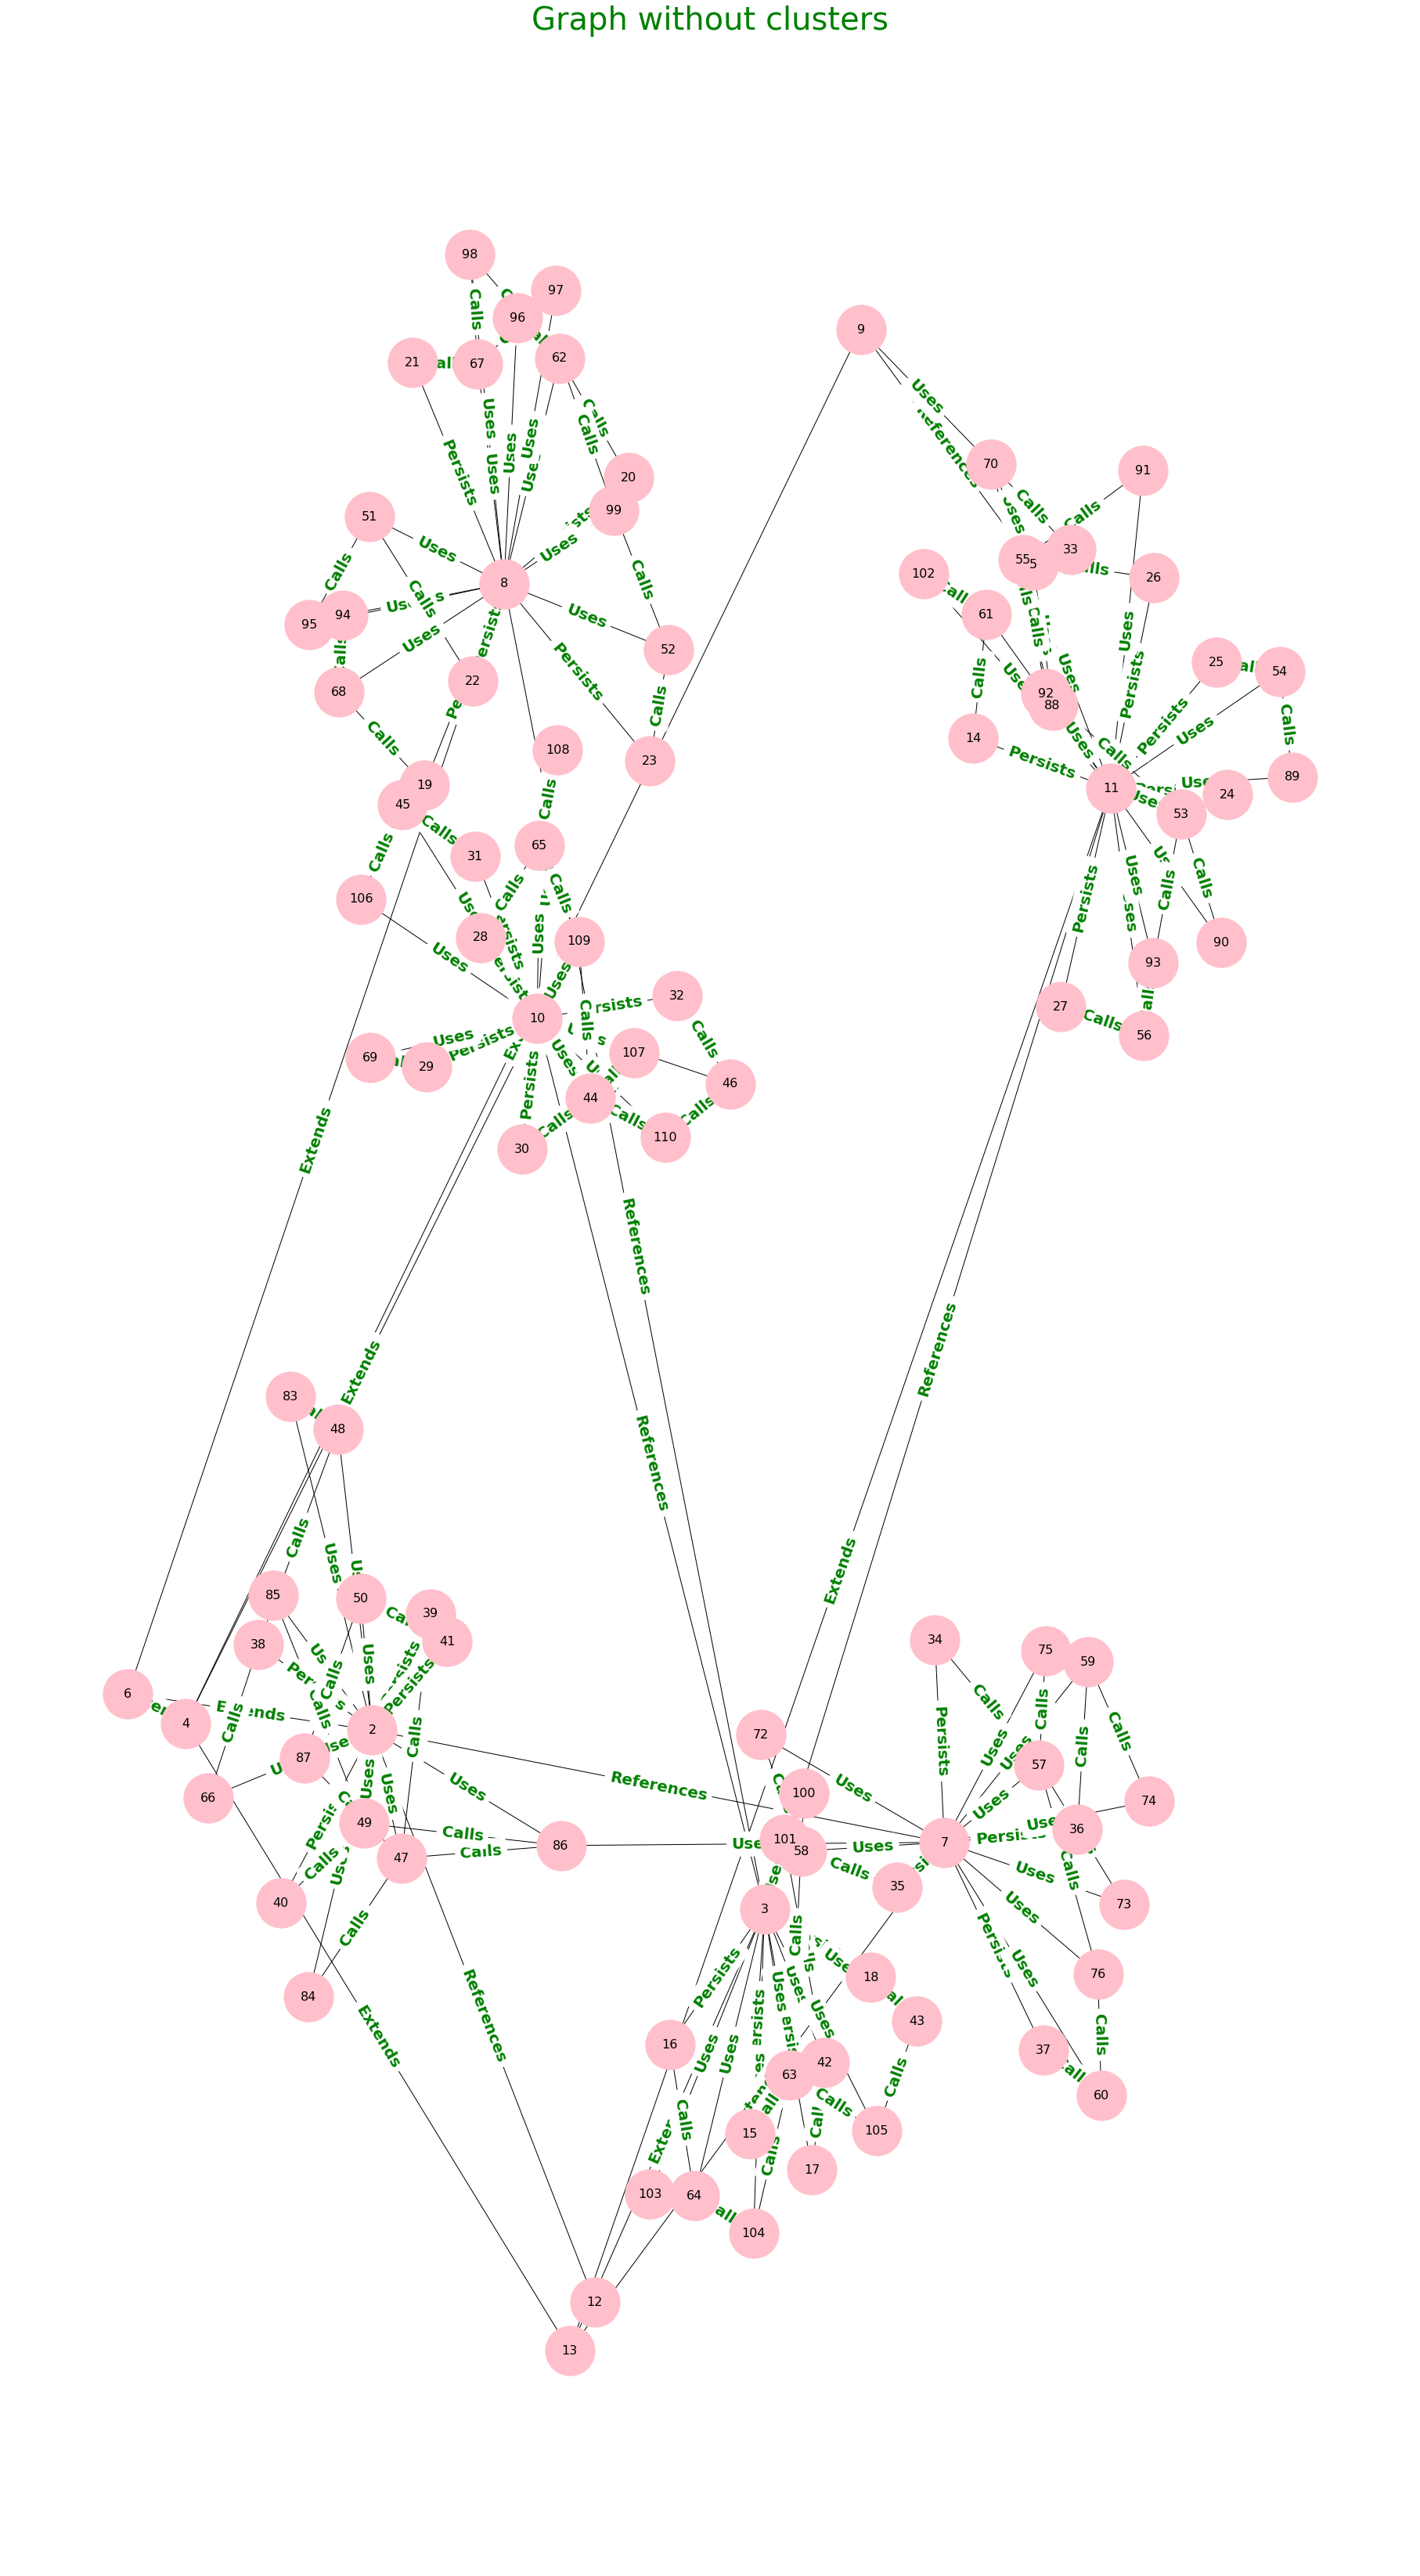

In [116]:
draw_graph(T,"Graph without clusters",None)

### 11.1 Louvain Community (best partition)

In [117]:
# compute the best petclinicPartition
#community.best_partition(graph, petclinicPartition=None, weight=’weight’, resolution=1.0, randomize= None, random_state=None)
petclinicPartition = community_louvain.best_partition(T)
#print(petclinicPartition)
#print("max partition values", max(petclinicPartition.values()))
#print("total", len(petclinicPartition.values()))
#print(petclinicPartition.keys())

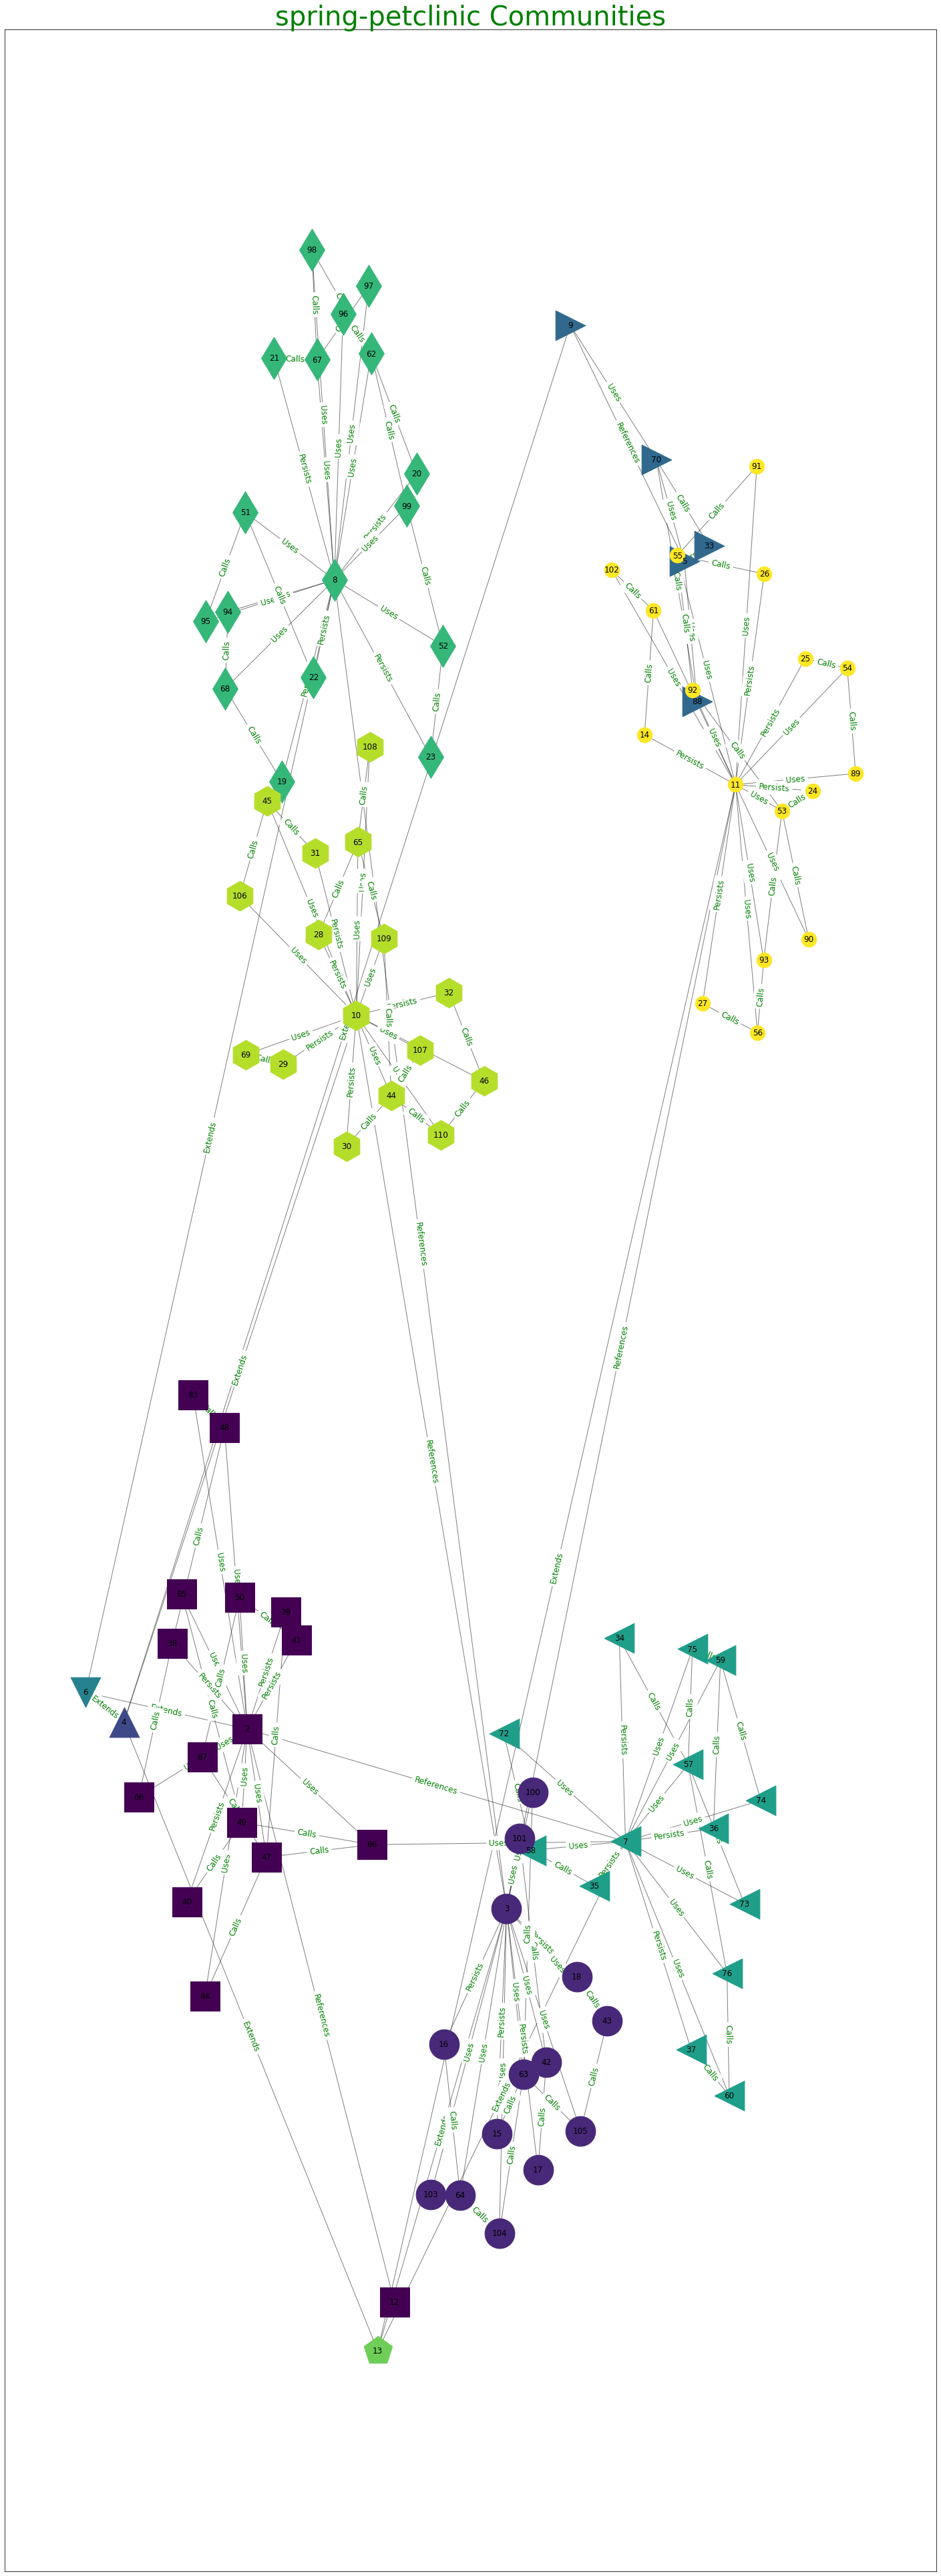

In [118]:
draw_community(T, petclinicPartition,"spring-petclinic Communities")

#### 11.1.1 Write best-partition to excel

In [ ]:
petclinicPartition_df = pd.DataFrame([petclinicPartition])
#print (partition_df)
with pd.ExcelWriter('GL10appsDataGraphs/Louvain-community-petclinic.xlsx') as writer:  
    petclinicPartition_df.to_excel(writer, sheet_name='petclinic')

 ### 11.2 Louvain Community Dendogram

In [133]:
#community.generate_dendrogram(graph, part_init=None, weight=’weight’, resolution=1.0, randomize=None, random_state=None)
petclinicDendo = community_louvain.generate_dendrogram(T)

In [134]:
len(petclinicDendo)

1

In [124]:
#print the dendogram cluster wrt each level
for level in range(len(petclinicDendo)) :
    print("partition at level", level, "is", community_louvain.partition_at_level(petclinicDendo, level), "\n")

partition at level 0 is {'2': 0, '3': 7, '4': 2, '5': 3, '6': 4, '7': 5, '8': 6, '9': 3, '10': 8, '11': 9, '12': 0, '13': 1, '14': 9, '15': 7, '16': 7, '17': 7, '18': 7, '19': 6, '20': 6, '21': 6, '22': 6, '23': 6, '24': 9, '25': 9, '26': 9, '27': 9, '28': 8, '29': 8, '30': 8, '31': 8, '32': 8, '33': 3, '34': 5, '35': 5, '36': 5, '37': 5, '38': 0, '39': 0, '40': 0, '41': 0, '42': 7, '43': 7, '44': 8, '45': 8, '46': 8, '47': 0, '48': 0, '49': 0, '50': 0, '51': 6, '52': 6, '53': 9, '54': 9, '55': 9, '56': 9, '57': 5, '58': 5, '59': 5, '60': 5, '61': 9, '62': 6, '63': 7, '64': 7, '65': 8, '66': 0, '67': 6, '68': 6, '69': 8, '70': 3, '72': 5, '73': 5, '74': 5, '75': 5, '76': 5, '83': 0, '84': 0, '85': 0, '86': 0, '87': 0, '88': 3, '89': 9, '90': 9, '91': 9, '92': 9, '93': 9, '94': 6, '95': 6, '96': 6, '97': 6, '98': 6, '99': 6, '100': 7, '101': 7, '102': 9, '103': 7, '104': 7, '105': 7, '106': 8, '107': 8, '108': 8, '109': 8, '110': 8} 



 #### 11.2.1 Louvain community - get each level from dendogram

In [125]:
#Level 0
petclinicPart0 = community_louvain.partition_at_level(petclinicDendo, 0)

In [ ]:
#Level 1
petclinicPart1 = community_louvain.partition_at_level(petclinicDendo, 1)

#### 11.2.2 Louvain community - draw each level from dendogram

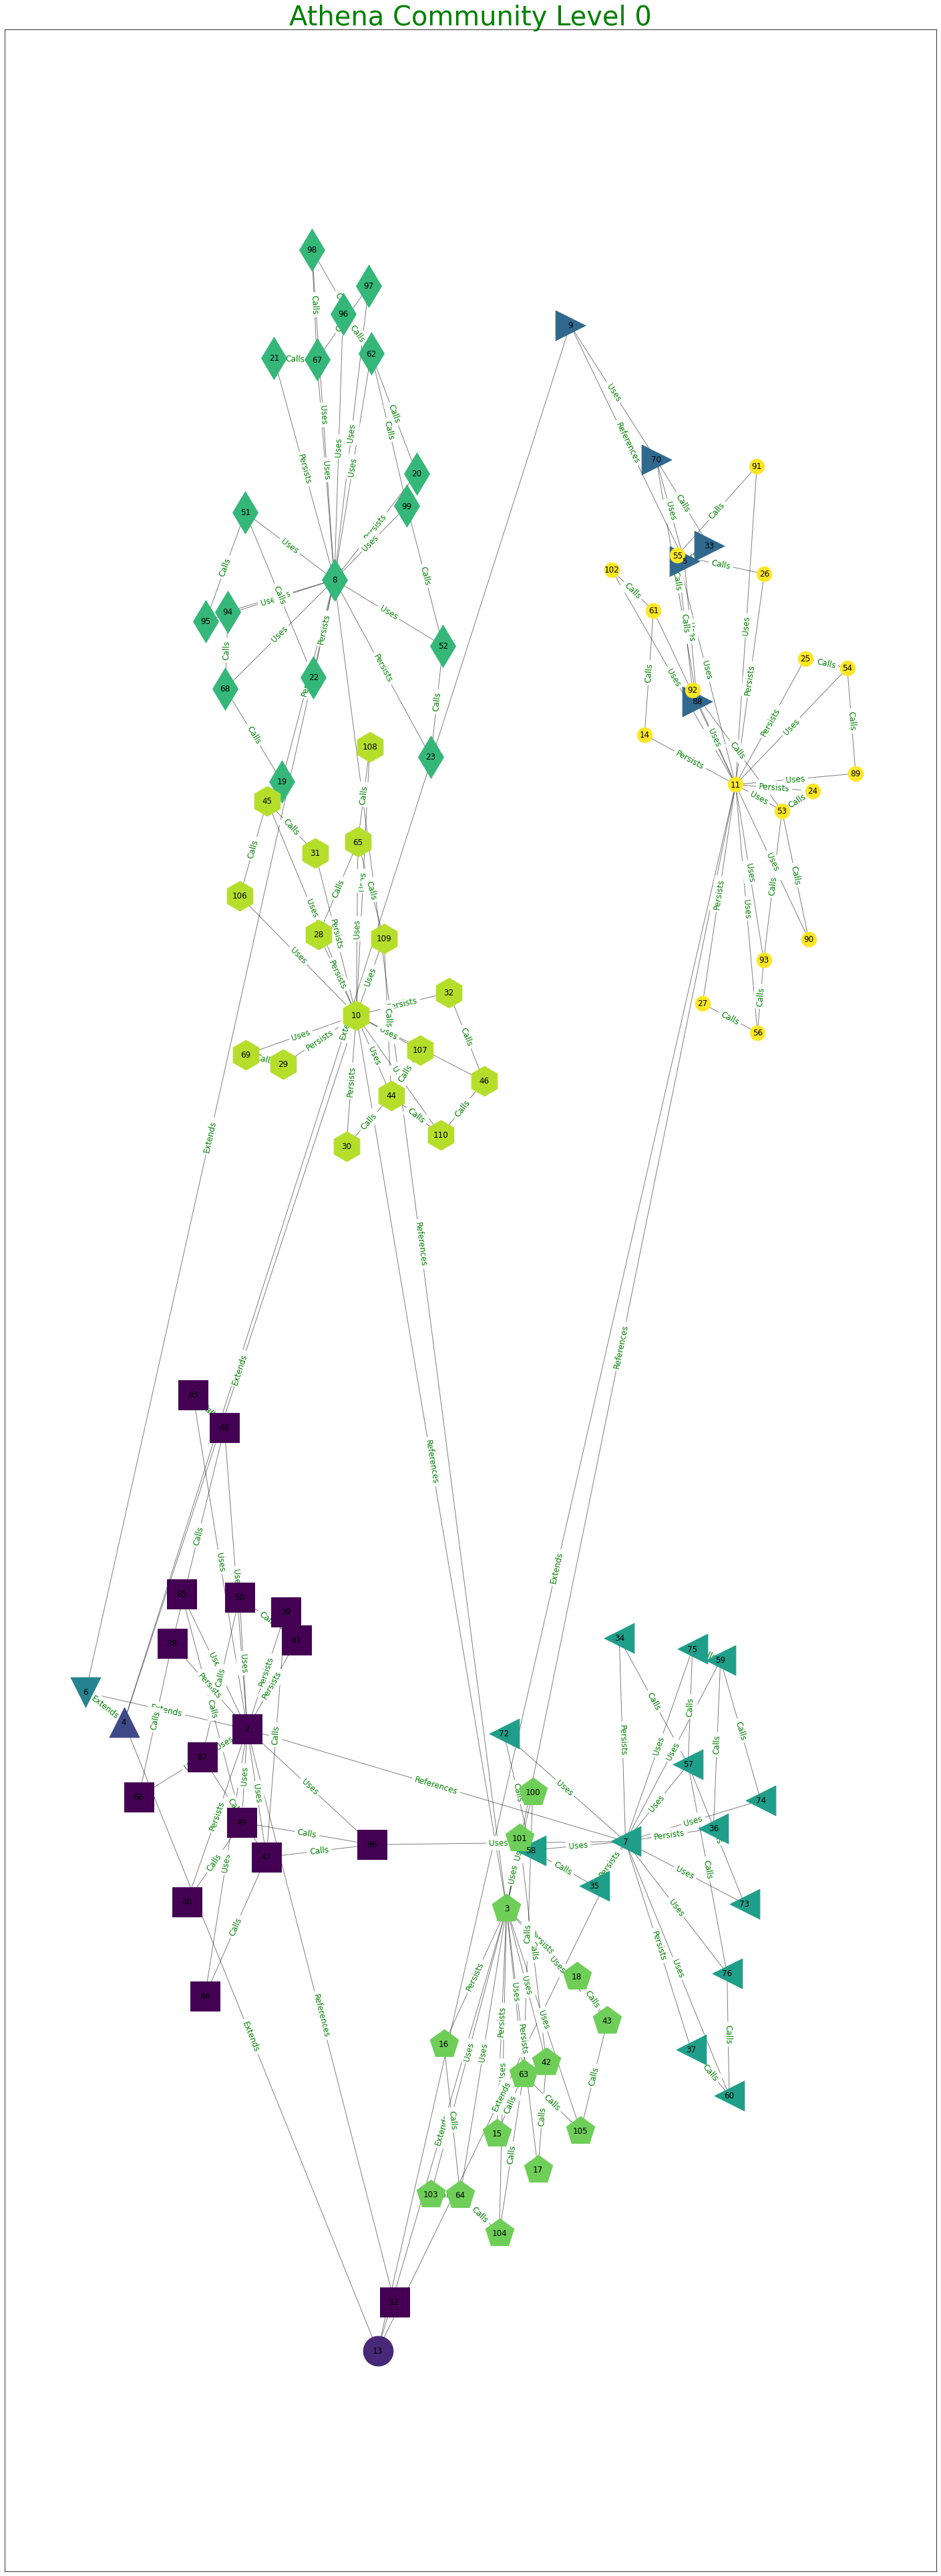

In [126]:
#draw_graph(petclinicPart0,"Athena Community Level 0",None)
draw_community(T,petclinicPart0,"Athena Community Level 0")

In [ ]:
#draw_graph(petclinicPart0,"Athena Community Level 0",None)
draw_community(T,petclinicPart1,"Athena Community Level 1")

#### 11.2.3 save louvain dendogram to excel wrt levels

In [128]:
#convert the partition dictionary to the dataframe
petclinicPart0_df = pd.DataFrame([petclinicPart0])

#write to the excel each partition on each sheet
with pd.ExcelWriter('GL10appsDataGraphs/Louvain-PetclinicCommunity.xlsx') as writer:  
    petclinicPart0_df.to_excel(writer, sheet_name='petclinic0')

# 12. Export to EXCEL

In [ ]:
with pd.ExcelWriter('GL10appsDataGraphs/Louvain-community-all.xlsx') as writer:  
    sample_df.to_excel(writer, sheet_name='Athena')#1
    EduMgmt_df.to_excel(writer, sheet_name='EduMgmt')#2
    ExamSysMgmt_df.to_excel(writer, sheet_name='ExamSys')#3
    JpetStorePartition_df.to_excel(writer, sheet_name='jpetstore')#4
    metelSOS_df.to_excel(writer, sheet_name='metelSOS')#5
    monolith2microservices_df.to_excel(writer, sheet_name='monolith2microservices')#6
    nanfeng_df.to_excel(writer, sheet_name='nanfeng')#7
    onlineJudge_df.to_excel(writer, sheet_name='onlineJudge')#8
    petHospital_df.to_excel(writer, sheet_name='petHospital')#9
    springblog_df.to_excel(writer, sheet_name='springblog') #10